# Gundam Sales Predictor

In [1]:
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


In [2]:
SUBSERIES = [
    {'universo': 'Universal Century', 'subserie': '0079', 'brand': 1.30, 'recency': 14, 'weight': 14},
    {'universo': 'Universal Century', 'subserie': 'Zeta', 'brand': 1.16, 'recency': 22, 'weight': 9},
    {'universo': 'Universal Century', 'subserie': 'CCA', 'brand': 1.20, 'recency': 18, 'weight': 8},
    {'universo': 'Universal Century', 'subserie': 'Unicorn', 'brand': 1.26, 'recency': 7, 'weight': 11},
    {'universo': 'Universal Century', 'subserie': 'Hathaway', 'brand': 1.22, 'recency': 3, 'weight': 7},
    {'universo': 'Gundam SEED', 'subserie': 'SEED', 'brand': 1.18, 'recency': 3, 'weight': 11},
    {'universo': 'Gundam SEED', 'subserie': 'SEED Destiny', 'brand': 1.05, 'recency': 8, 'weight': 8},
    {'universo': 'Gundam 00', 'subserie': 'Gundam 00 S1', 'brand': 1.00, 'recency': 16, 'weight': 7},
    {'universo': 'Gundam 00', 'subserie': 'A Wakening of the Trailblazer', 'brand': 0.95, 'recency': 14, 'weight': 4},
    {'universo': 'IBO', 'subserie': 'Iron-Blooded Orphans', 'brand': 1.08, 'recency': 10, 'weight': 10},
    {'universo': 'Witch from Mercury', 'subserie': 'WFM S1', 'brand': 1.15, 'recency': 2, 'weight': 9},
    {'universo': 'Witch from Mercury', 'subserie': 'WFM S2', 'brand': 1.12, 'recency': 1, 'weight': 8}
]

GRADE_CONFIG = {
    'SD': {'escala': 'SD', 'p_min': 700, 'p_max': 1600, 'base': 24000},
    'HG': {'escala': '1/144', 'p_min': 2200, 'p_max': 3900, 'base': 47000},
    'RG': {'escala': '1/144', 'p_min': 3200, 'p_max': 5200, 'base': 28000},
    'MG': {'escala': '1/100', 'p_min': 4800, 'p_max': 9800, 'base': 17000},
    'PG': {'escala': '1/60', 'p_min': 22000, 'p_max': 32000, 'base': 4500}
}

ROLE_MULTIPLIER = {
    'protagonista': 1.30,
    'rival': 1.16,
    'elite': 1.02,
    'grunt': 0.86,
    'support': 0.92
}

RELEASE_MULTIPLIER = {
    'nuevo': 1.10,
    'ver_ka': 1.15,
    '2.0': 1.08,
    'revive': 1.03,
    'recolor': 0.78
}

DIST_MULTIPLIER = {
    'Regular': 1.18,
    'P-Bandai': 0.82,
    'Event': 0.62
}


In [3]:
def generate_gundam_market_dataset(n_samples=3000, seed=42):
    random.seed(seed)
    np.random.seed(seed)
    data = []

    subseries_weights = [item['weight'] for item in SUBSERIES]
    grade_options = list(GRADE_CONFIG.keys())

    for _ in range(n_samples):
        grado = random.choices(grade_options, weights=[12, 42, 17, 20, 9])[0]
        conf = GRADE_CONFIG[grado]
        serie = random.choices(SUBSERIES, weights=subseries_weights)[0]
        universo = serie['universo']
        subserie = serie['subserie']
        universe_brand = serie['brand']

        suit_role = random.choices(
            ['protagonista', 'rival', 'elite', 'grunt', 'support'],
            weights=[20, 15, 18, 32, 15]
        )[0]

        release_type = random.choices(
            ['nuevo', 'ver_ka', '2.0', 'revive', 'recolor'],
            weights=[45, 8, 12, 20, 15]
        )[0]

        years_since_media = max(0, int(np.random.normal(serie['recency'], 2.2)))
        anime_on_air = int(years_since_media <= 1 and random.random() < 0.75)
        anniversary_boost = int(universo == 'Universal Century' and years_since_media >= 10 and random.random() < 0.28)

        if grado == 'PG':
            distribucion = random.choices(['P-Bandai', 'Regular'], weights=[70, 30])[0]
        elif release_type == 'recolor':
            distribucion = random.choices(['P-Bandai', 'Regular', 'Event'], weights=[50, 35, 15])[0]
        else:
            distribucion = random.choices(['Regular', 'P-Bandai', 'Event'], weights=[72, 23, 5])[0]

        price_span = conf['p_max'] - conf['p_min']
        role_price_push = {'protagonista': 0.10, 'rival': 0.06, 'elite': 0.03, 'grunt': -0.02, 'support': 0.0}[suit_role]
        release_price_push = {'nuevo': 0.02, 'ver_ka': 0.15, '2.0': 0.10, 'revive': -0.03, 'recolor': -0.05}[release_type]
        price_ratio = np.clip(np.random.normal(0.50 + role_price_push + release_price_push, 0.15), 0.05, 0.98)
        precio = int(conf['p_min'] + price_ratio * price_span)

        saturation = np.clip(
            np.random.normal(
                0.30
                + (0.16 if universo == 'Universal Century' else 0.0)
                + (0.12 if release_type == 'recolor' else 0.0)
                + (0.08 if suit_role == 'protagonista' else 0.0),
                0.12
            ),
            0,
            1
        )

        announcement_boost = np.clip(np.random.normal(0.18 if release_type in ['nuevo', 'ver_ka', '2.0'] else 0.05, 0.08), 0, 0.35)
        recency_signal = np.exp(-years_since_media / 8)
        hype_score = np.clip(
            0.38 * anime_on_air
            + 0.27 * recency_signal
            + 0.15 * announcement_boost
            + (0.06 if suit_role in ['protagonista', 'rival'] else 0.0)
            + np.random.normal(0, 0.05),
            0,
            1
        )

        hidden_suit_popularity = np.clip(
            np.random.normal(
                0.62
                + (0.17 if suit_role == 'protagonista' else 0.0)
                + (0.10 if suit_role == 'rival' else 0.0)
                + (0.08 if subserie in ['0079', 'Unicorn', 'SEED', 'WFM S1'] else 0.0),
                0.12
            ),
            0.2,
            1.25
        )

        demand_proxy = np.clip(
            45
            + 28 * universe_brand
            + 14 * ROLE_MULTIPLIER[suit_role]
            + 18 * hype_score
            - 12 * saturation
            + np.random.normal(0, 6),
            5,
            99
        )

        price_penalty = np.clip(1.05 - 0.35 * ((precio - conf['p_min']) / max(price_span, 1)), 0.62, 1.08)
        anniversary_multiplier = 1.08 if anniversary_boost else 1.0
        media_decay = np.clip(1.08 - 0.012 * years_since_media, 0.70, 1.08)
        saturation_penalty = np.clip(1.05 - 0.22 * saturation, 0.72, 1.05)

        ventas_totales = int(
            conf['base']
            * universe_brand
            * ROLE_MULTIPLIER[suit_role]
            * RELEASE_MULTIPLIER[release_type]
            * DIST_MULTIPLIER[distribucion]
            * (0.92 + 0.36 * hidden_suit_popularity)
            * (0.92 + 0.30 * hype_score)
            * anniversary_multiplier
            * media_decay
            * saturation_penalty
            * price_penalty
            * np.random.normal(1.0, 0.08)
        )

        data.append({
            'grado': grado,
            'escala': conf['escala'],
            'universo': universo,
            'subserie': subserie,
            'suit_role': suit_role,
            'release_type': release_type,
            'precio': precio,
            'distribucion': distribucion,
            'anime_on_air': anime_on_air,
            'years_since_media': years_since_media,
            'anniversary_boost': anniversary_boost,
            'saturation': saturation,
            'hype_score': hype_score,
            'demand_proxy': demand_proxy,
            'ventas_totales': max(ventas_totales, 300)
        })

    df = pd.DataFrame(data)
    df['precio_relativo'] = df['precio'] / df.groupby('grado')['precio'].transform('mean')
    # Logica anterior: comparaba P-Bandai, Event y Regular contra el mismo benchmark de volumen.
    # df['exito_comercial'] = df.groupby('grado')['ventas_totales'].transform(
    #     lambda x: (x - x.min()) / (x.max() - x.min())
    # )
    # Nueva logica: el exito se mide dentro del canal de distribucion para no castigar exclusividad.
    df['exito_comercial'] = df.groupby(['grado', 'distribucion'])['ventas_totales'].transform(
        lambda x: 0.5 if x.max() == x.min() else (x - x.min()) / (x.max() - x.min())
    )
    df['ventas_relativas_canal'] = df['ventas_totales'] / df.groupby(['grado', 'distribucion'])['ventas_totales'].transform('mean')
    return df


In [4]:
df = generate_gundam_market_dataset(n_samples=2000, seed=42)
df.head()


,grado,escala,universo,subserie,suit_role,release_type,precio,distribucion,anime_on_air,years_since_media,anniversary_boost,saturation,hype_score,demand_proxy,ventas_totales,precio_relativo,exito_comercial,ventas_relativas_canal
0,RG,1/144,Universal Century,0079,rival,nuevo,4318,Regular,0,15,0,0.537723,0.134975,99.000000,47948,1.002126,0.555587,1.237988
1,MG,1/100,Universal Century,0079,elite,nuevo,7956,Regular,0,12,1,0.404390,0.093754,82.165395,23245,1.067651,0.347659,0.968276
2,SD,SD,Universal Century,Zeta,grunt,2.0,1264,Regular,0,19,1,0.351037,0.108449,87.664801,21702,1.067110,0.091144,0.657446
3,MG,1/100,Universal Century,0079,grunt,revive,7133,Regular,0,12,0,0.321881,0.042222,86.727180,23307,0.957209,0.349413,0.970858
4,PG,1/60,Universal Century,Unicorn,protagonista,nuevo,26613,Regular,0,6,0,0.638705,0.210332,86.632395,8938,0.970523,0.700586,1.427398


In [5]:
df[['universo', 'subserie', 'suit_role', 'release_type', 'distribucion', 'hype_score', 'ventas_totales', 'ventas_relativas_canal', 'exito_comercial']].sample(8, random_state=42)


,universo,subserie,suit_role,release_type,distribucion,hype_score,ventas_totales,ventas_relativas_canal,exito_comercial
1860,Gundam SEED,SEED,rival,nuevo,Regular,0.306791,77466,1.194163,0.462572
353,Universal Century,0079,elite,revive,Regular,0.107495,30585,0.789686,0.224315
1333,Universal Century,CCA,support,nuevo,Regular,0.066382,26614,0.806252,0.180469
905,Witch from Mercury,WFM S1,grunt,nuevo,P-Bandai,0.239798,45007,1.092610,0.431014
1289,Universal Century,0079,protagonista,recolor,P-Bandai,0.199866,17129,1.088061,0.437793
1273,Witch from Mercury,WFM S1,protagonista,2.0,Regular,0.735681,60247,1.555541,0.790243
938,Gundam SEED,SEED Destiny,rival,recolor,P-Bandai,0.147522,46273,1.123344,0.453217
1731,Gundam SEED,SEED,grunt,recolor,Regular,0.264826,44050,0.679045,0.151916


## Entrenamiento

Usamos un `RandomForestRegressor`

In [ ]:
feature_cols = [
    'grado',
    'universo',
    'subserie',
    'suit_role',
    'release_type',
    'distribucion',
    'anime_on_air',
    'years_since_media',
    'anniversary_boost',
    'saturation',
    'precio_relativo',
    'hype_score',
    'demand_proxy'
]

X = df[feature_cols]
y = df['exito_comercial']

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

numeric_features = [
    'anime_on_air',
    'years_since_media',
    'anniversary_boost',
    'saturation',
    'precio_relativo',
    'hype_score',
    'demand_proxy'
]

categorical_features = [
    'grado',
    'universo',
    'subserie',
    'suit_role',
    'release_type',
    'distribucion'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

modelo = Pipeline(steps=[ #hyperparametros, 250 arboles, criterio MAE, max_features= raiz cuadrada del total de features, max_depth None, min_samples_leaf 2, oob_score True 
                         #min_samples_leaf 2, oob_score True
                         
    ('preprocesar', preprocessor),
    ('regresor', RandomForestRegressor(
        n_estimators=250,
        criterion='absolute_error',
        max_features='sqrt',
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
        oob_score=True
    ))
])

modelo.fit(x_train, y_train)
pred_test = modelo.predict(x_test)

print('R2:', round(r2_score(y_test, pred_test), 4))
print('MAE:', round(mean_absolute_error(y_test, pred_test), 4))
print('OOB:', round(modelo.named_steps['regresor'].oob_score_, 4))


R2: 0.7438
MAE: 0.0747
OOB: 0.7504


## Diagnóstico de importancia

Aquí usamos permutation importance sobre las columnas originales. Esto evita perdernos dentro del `OneHotEncoder` y deja claro si `hype` sigue demasiado arriba o si ahora comparte espacio con `universo/subserie`.


In [ ]:
perm = permutation_importance( 
    x_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    'feature': x_test.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

importance_df


,feature,importance_mean,importance_std
3,suit_role,0.466155,0.020731
4,release_type,0.118971,0.007747
11,hype_score,0.111770,0.012203
7,years_since_media,0.059401,0.008370
2,subserie,0.041040,0.003509
1,universo,0.033263,0.006702
12,demand_proxy,0.026961,0.005320
10,precio_relativo,0.017050,0.003218
5,distribucion,0.015575,0.001955
0,grado,0.013720,0.002016


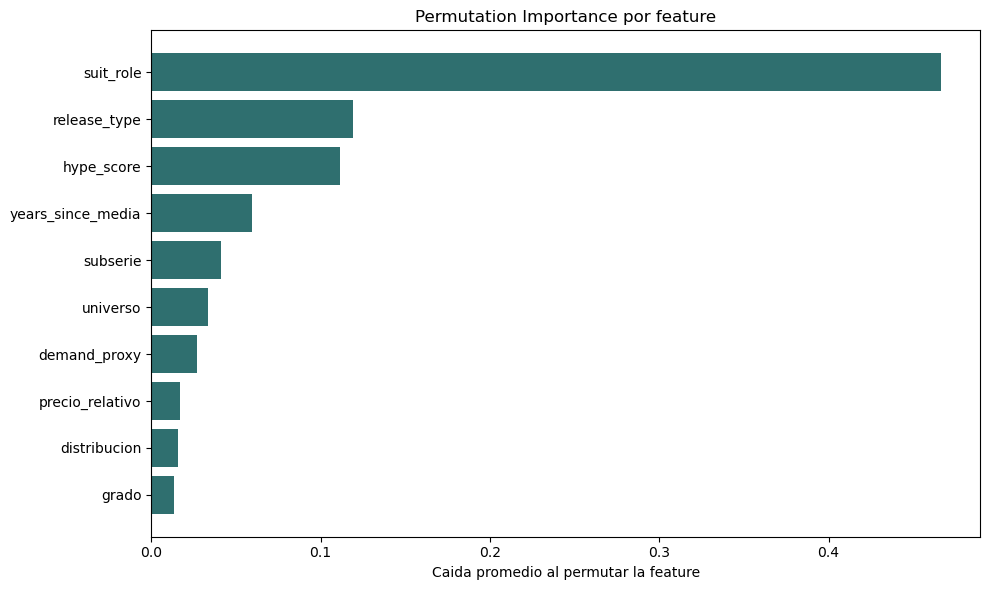

In [8]:
top_n = 10
plot_df = importance_df.head(top_n).sort_values('importance_mean')

plt.figure(figsize=(10, 6))
plt.barh(plot_df['feature'], plot_df['importance_mean'], color='#2f6f6f')
plt.title('Permutation Importance por feature')
plt.xlabel('Caida promedio al permutar la feature')
plt.tight_layout()
plt.show()


In [ ]:
joblib.dump(modelo, 'modelo_gundam_v3.pkl')
print('Modelo guardado   como modelo_gundam_v3.pkl')


Modelo guardado como modelo_gundam_v3.pkl
